## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [2]:
df=pd.read_csv("WineQT.csv")

## Basic Inspection for understanding the dataset

In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [4]:
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595
1142,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,1597


In [5]:
df.shape

(1143, 13)

In [6]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [8]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [9]:
df.isnull().mean()*100

fixed acidity           0.0
volatile acidity        0.0
citric acid             0.0
residual sugar          0.0
chlorides               0.0
free sulfur dioxide     0.0
total sulfur dioxide    0.0
density                 0.0
pH                      0.0
sulphates               0.0
alcohol                 0.0
quality                 0.0
Id                      0.0
dtype: float64

In [10]:
df.duplicated().sum()

np.int64(0)

## Check Original Quality Distribution

In [11]:
df['quality'].value_counts().sort_index()

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

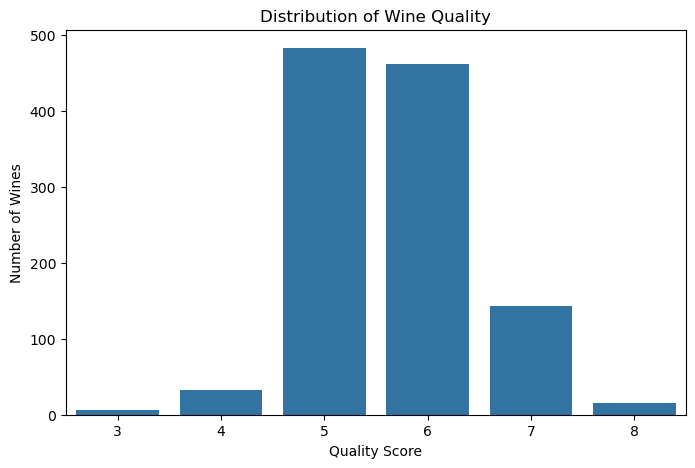

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='quality'
)

plt.title('Distribution of Wine Quality')
plt.xlabel('Quality Score')
plt.ylabel('Number of Wines')

plt.show()

Observation:
* The quality classes are imbalanced. Quality scores 5 and 6 represent the majority of observations, while scores 3 and 8 are severely underrepresented. This imbalance can cause classification models to favor the majority classes and perform poorly on rare quality categories.

## Feature Engineering

In [13]:
def quality_category(q):
    if q <= 5:
        return 'Low'
    elif q == 6:
        return 'Medium'
    else:
        return 'High'

df['quality_category'] = df['quality'].apply(quality_category)

In [14]:
df['quality_category'].value_counts()

quality_category
Low       522
Medium    462
High      159
Name: count, dtype: int64

## Visualize the New Classes

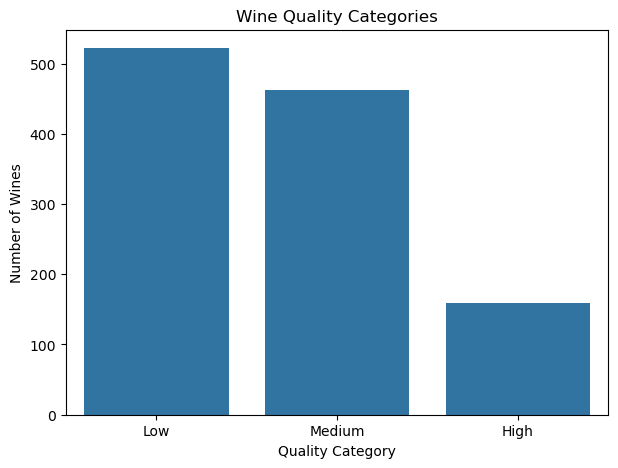

In [15]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='quality_category',
    order=['Low', 'Medium', 'High']
)

plt.title('Wine Quality Categories')
plt.xlabel('Quality Category')
plt.ylabel('Number of Wines')

plt.show()

Observation:
* After binning the quality scores into Low, Medium, and High categories, the class distribution becomes less imbalanced than the original six-class problem. However, the High-quality category remains comparatively underrepresented.

## EDA-Distribution Plots for All Chemical Features

In [16]:
features = [
    'fixed acidity',
    'volatile acidity',
    'citric acid',
    'residual sugar',
    'chlorides',
    'free sulfur dioxide',
    'total sulfur dioxide',
    'density',
    'pH',
    'sulphates',
    'alcohol'
]

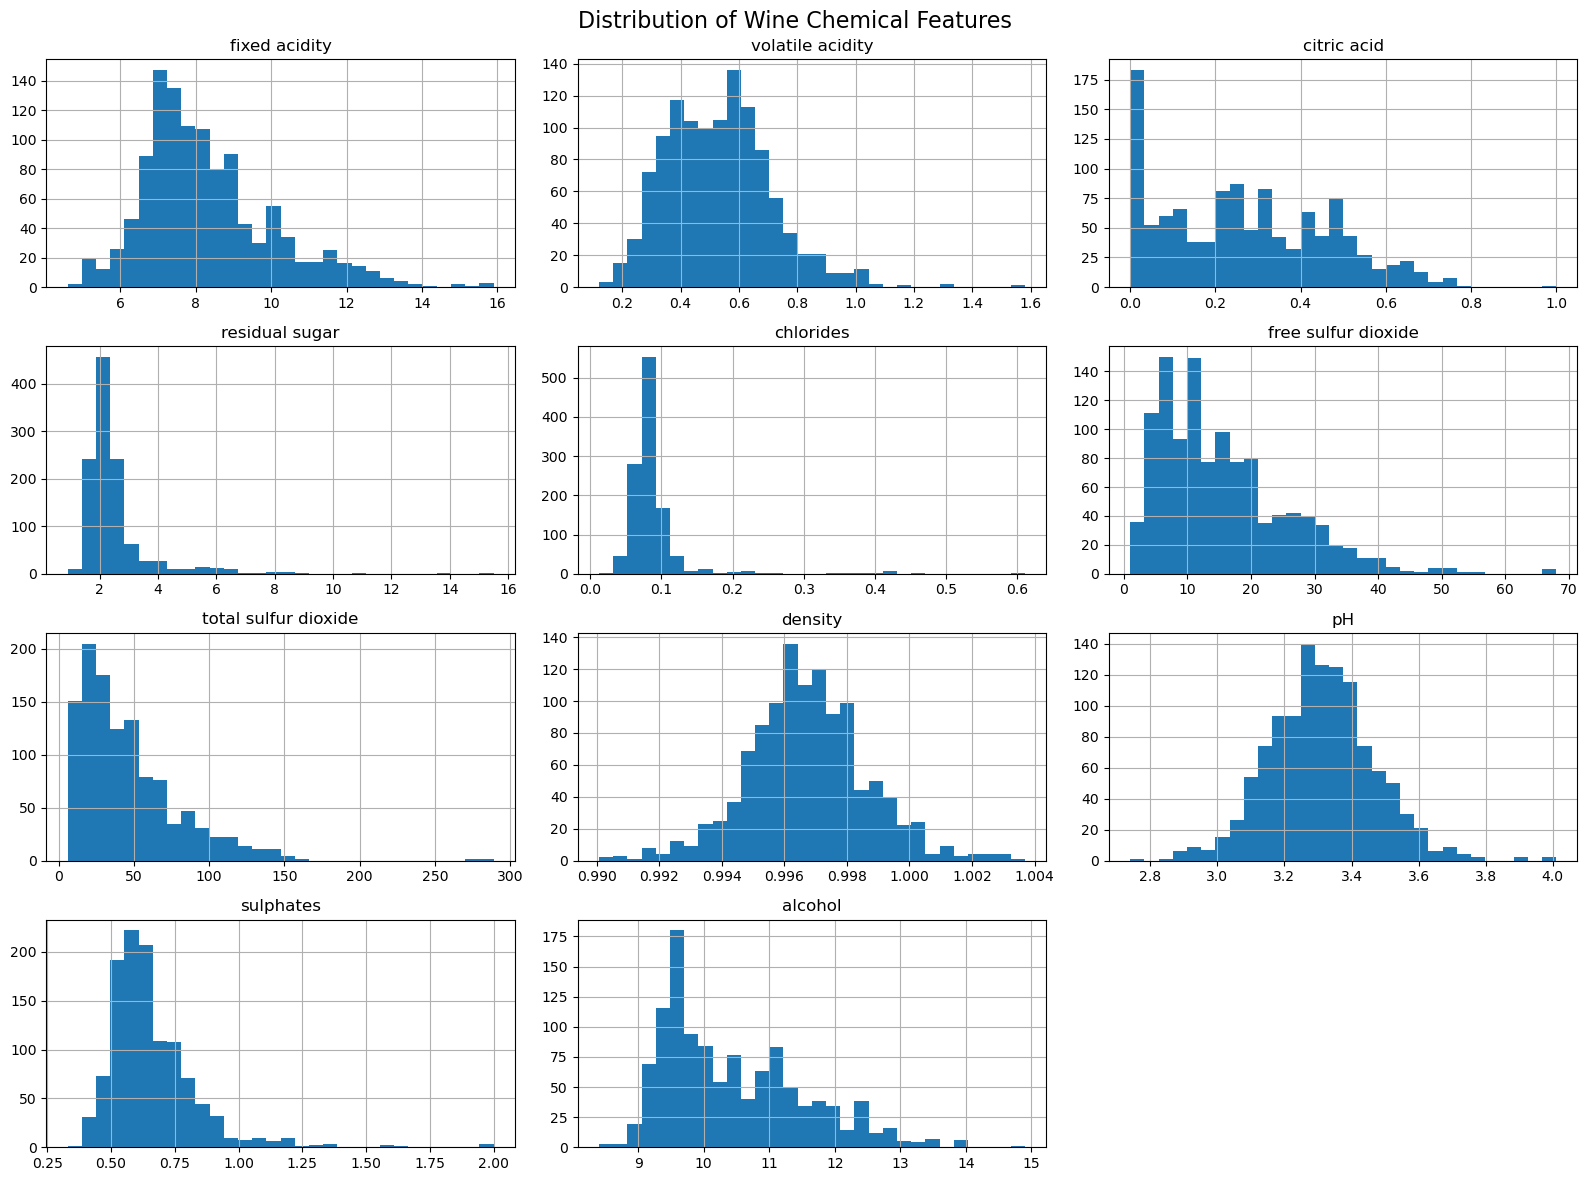

In [17]:
df[features].hist(
    figsize=(16,12),
    bins=30
)

plt.suptitle(
    'Distribution of Wine Chemical Features',
    fontsize=16
)

plt.tight_layout()
plt.show()

## Correlation Heatmap

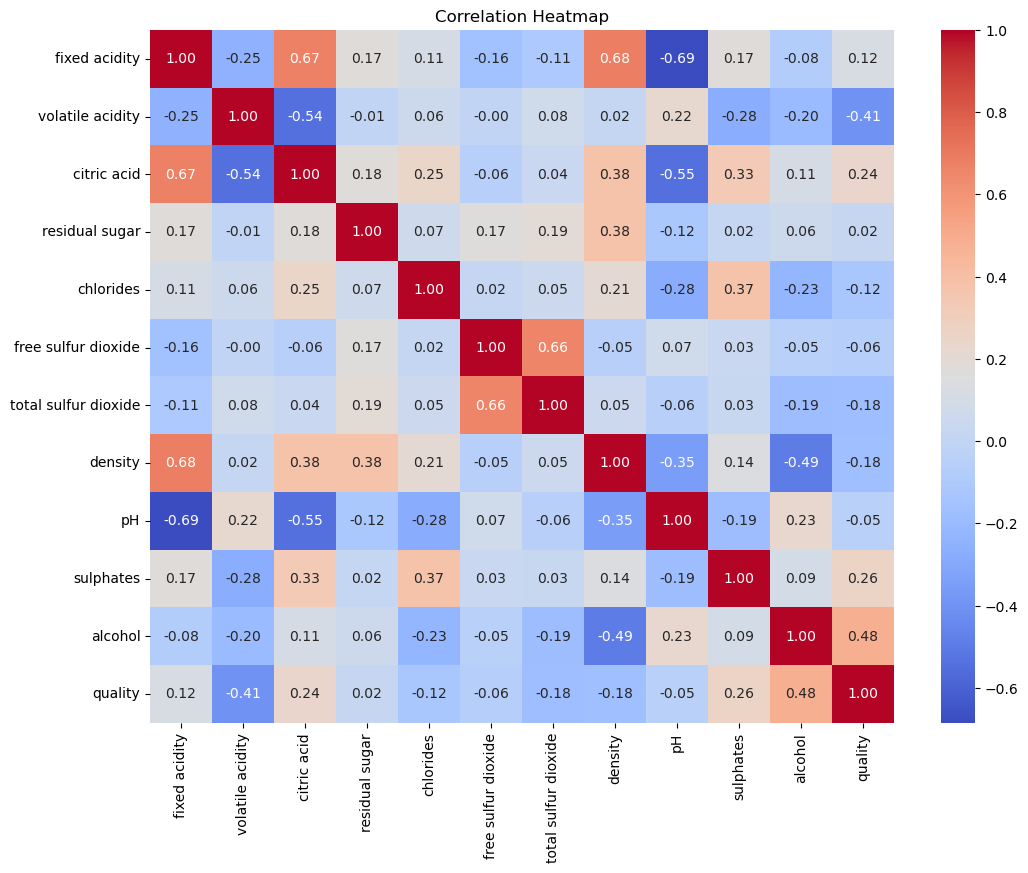

In [18]:
plt.figure(figsize=(12,9))

corr = df[features + ['quality']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

Observation:
**The strongest relationship with quality is:**
* Alcohol: positive relationship

* Volatile acidity: negative relationship

* Sulphates: positive relationship

* Citric acid: positive relationship

* Density: negative relationship

* Total sulfur dioxide: negative relationship.

* Alcohol has the strongest positive linear correlation with wine quality, while volatile acidity has a relatively strong negative correlation. These relationships suggest that these variables may provide useful predictive information, although correlation alone does not determine model performance.

## Define X and Y

In [23]:
X = df[features]

Y = df['quality_category']

In [25]:
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [26]:
Y.head()

0       Low
1       Low
2       Low
3    Medium
4       Low
Name: quality_category, dtype: object

## Train-Test-Split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
print("Training distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True))

Training distribution:
quality_category
Low       0.456236
Medium    0.404814
High      0.138950
Name: proportion, dtype: float64

Testing distribution:
quality_category
Low       0.458515
Medium    0.401747
High      0.139738
Name: proportion, dtype: float64


## Feature Scaling

In [29]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [30]:
scaler.fit_transform(X_train)

array([[ 0.51397474, -0.0565154 ,  3.72724493, ..., -3.68647454,
         7.76408834, -0.95057374],
       [-0.05379528,  0.33396574, -1.36704105, ...,  1.20637884,
        -0.03895514, -1.04167572],
       [-0.90545031,  0.8081214 , -1.01044103, ...,  0.2406841 ,
        -0.67475868, -0.31285988],
       ...,
       [-0.7351193 ,  0.16661668, -0.70478388, ...,  0.17630445,
        -0.38575707, -1.1327777 ],
       [ 0.74108275,  0.38974876,  1.18010194, ...,  1.20637884,
        -0.50135772, -0.6772678 ],
       [-0.56478829,  1.17071103, -0.95949817, ..., -0.46749205,
        -0.90595997, -0.58616582]], shape=(914, 11))

In [31]:
scaler.transform(X_test)

array([[ 0.74108275,  0.16661668,  0.2121876 , ..., -1.3044275 ,
         1.52165356, -0.40396186],
       [ 0.11653573,  0.69655536,  1.12915908, ..., -0.0168345 ,
         2.79326064, -1.04167572],
       [ 0.62752875, -0.16808144,  0.36501618, ..., -0.1455938 ,
        -0.79035933,  0.233752  ],
       ...,
       [-0.6215653 ,  0.50131479, -1.31609819, ...,  0.04754515,
        -0.84815965,  1.23587377],
       [ 0.34364374,  1.22649405, -0.65384102, ...,  0.17630445,
        -0.09675546,  0.05154804],
       [-0.56478829,  2.5095035 , -1.11232675, ..., -0.0168345 ,
        -0.61695836, -0.6772678 ]], shape=(229, 11))

## Model-1:-Random Forest

In [32]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

In [33]:
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Prediction

In [34]:
y_pred_rf = rf.predict(X_test)

## Evaluate Random Forest

In [35]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.6899563318777293


In [36]:
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

        High       0.75      0.66      0.70        32
         Low       0.75      0.73      0.74       105
      Medium       0.61      0.65      0.63        92

    accuracy                           0.69       229
   macro avg       0.70      0.68      0.69       229
weighted avg       0.69      0.69      0.69       229



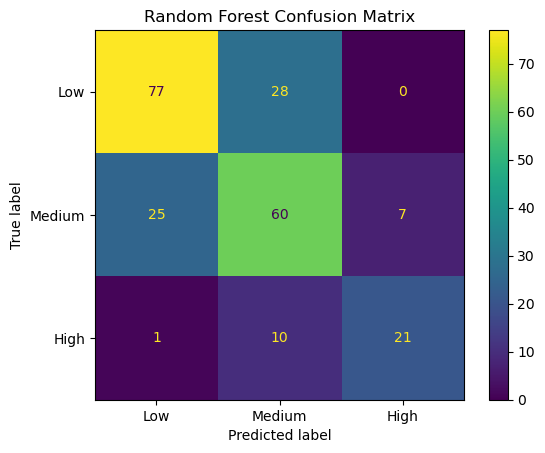

In [37]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=['Low', 'Medium', 'High']
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=['Low', 'Medium', 'High']
)

disp.plot()

plt.title('Random Forest Confusion Matrix')

plt.show()

## Random Forest Feature Importance

In [38]:
importance = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=False)

print(importance)

alcohol                 0.167578
sulphates               0.133364
volatile acidity        0.113058
citric acid             0.086904
total sulfur dioxide    0.084562
density                 0.081501
chlorides               0.076836
fixed acidity           0.069102
pH                      0.067361
residual sugar          0.060492
free sulfur dioxide     0.059241
dtype: float64


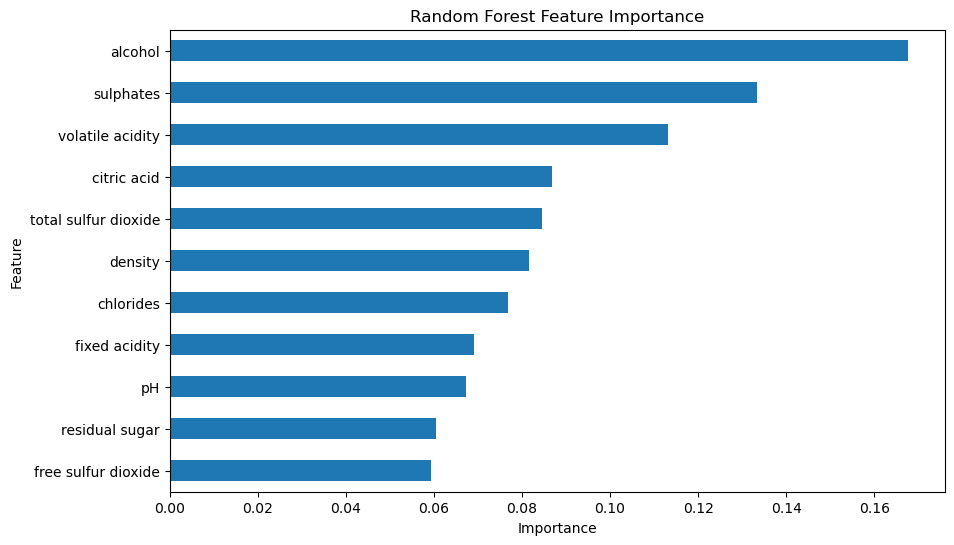

In [39]:
plt.figure(figsize=(10,6))

importance.sort_values().plot(
    kind='barh'
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

Observation:
* The Random Forest feature importance analysis identifies the chemical variables that contributed most to the model's predictions. These results can be used to understand which physicochemical characteristics are most informative for classification.

## Model-2:-SGD Classifier

In [40]:
sgd = SGDClassifier(
    random_state=42,
    max_iter=2000,
    class_weight='balanced'
)

In [41]:
sgd.fit(X_train_scaled, y_train)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,2000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [42]:
y_pred_sgd = sgd.predict(X_test_scaled)

**SGD Classifier Model Evaluation**

In [43]:
sgd_accuracy = accuracy_score(
    y_test,
    y_pred_sgd
)

print("SGD Accuracy:", sgd_accuracy)

print(
    classification_report(
        y_test,
        y_pred_sgd
    )
)

SGD Accuracy: 0.5327510917030568
              precision    recall  f1-score   support

        High       0.30      0.38      0.33        32
         Low       0.68      0.69      0.68       105
      Medium       0.46      0.41      0.43        92

    accuracy                           0.53       229
   macro avg       0.48      0.49      0.48       229
weighted avg       0.54      0.53      0.53       229



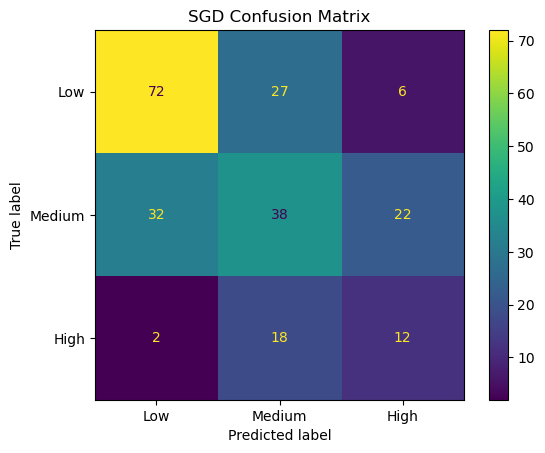

In [44]:
cm_sgd = confusion_matrix(
    y_test,
    y_pred_sgd,
    labels=['Low', 'Medium', 'High']
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_sgd,
    display_labels=['Low', 'Medium', 'High']
)

disp.plot()

plt.title('SGD Confusion Matrix')

plt.show()

## Model-3:-Support Vector Classifier

In [45]:
svc = SVC(
    kernel='rbf',
    class_weight='balanced',
    random_state=42
)

In [46]:
svc.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [47]:
y_pred_svc = svc.predict(X_test_scaled)

**SVC Model Evaluation**

In [48]:
svc_accuracy = accuracy_score(
    y_test,
    y_pred_svc
)

print("SVC Accuracy:", svc_accuracy)

print(
    classification_report(
        y_test,
        y_pred_svc
    )
)

SVC Accuracy: 0.62882096069869
              precision    recall  f1-score   support

        High       0.46      0.78      0.58        32
         Low       0.75      0.72      0.74       105
      Medium       0.58      0.47      0.52        92

    accuracy                           0.63       229
   macro avg       0.60      0.66      0.61       229
weighted avg       0.64      0.63      0.63       229



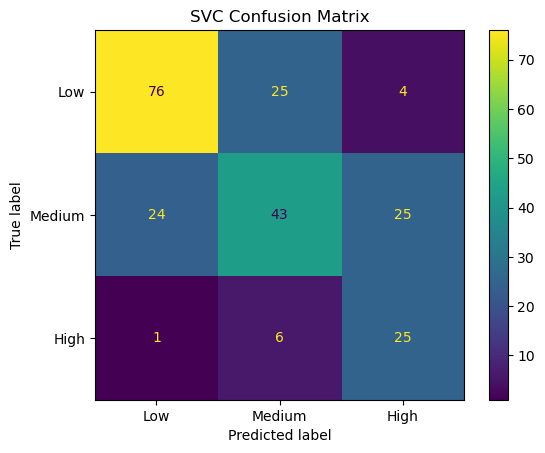

In [49]:
cm_svc = confusion_matrix(
    y_test,
    y_pred_svc,
    labels=['Low', 'Medium', 'High']
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svc,
    display_labels=['Low', 'Medium', 'High']
)

disp.plot()

plt.title('SVC Confusion Matrix')

plt.show()

## Compare All 3 Models

In [50]:
comparison = pd.DataFrame({
    'Model': [
        'Random Forest',
        'SGD Classifier',
        'SVC'
    ],

    'Accuracy': [
        rf_accuracy,
        sgd_accuracy,
        svc_accuracy
    ]
})

comparison

,Model,Accuracy
0,Random Forest,0.689956
1,SGD Classifier,0.532751
2,SVC,0.628821


In [51]:
from sklearn.metrics import precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    'Model': [
        'Random Forest',
        'SGD Classifier',
        'SVC'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_sgd),
        accuracy_score(y_test, y_pred_svc)
    ],

    'Precision': [
        precision_score(y_test, y_pred_rf, average='weighted'),
        precision_score(y_test, y_pred_sgd, average='weighted'),
        precision_score(y_test, y_pred_svc, average='weighted')
    ],

    'Recall': [
        recall_score(y_test, y_pred_rf, average='weighted'),
        recall_score(y_test, y_pred_sgd, average='weighted'),
        recall_score(y_test, y_pred_svc, average='weighted')
    ],

    'F1 Score': [
        f1_score(y_test, y_pred_rf, average='weighted'),
        f1_score(y_test, y_pred_sgd, average='weighted'),
        f1_score(y_test, y_pred_svc, average='weighted')
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.689956,0.693544,0.689956,0.691029
1,SGD Classifier,0.532751,0.537298,0.532751,0.533973
2,SVC,0.628821,0.643162,0.628821,0.627699


## Create a Model Comparison Chart

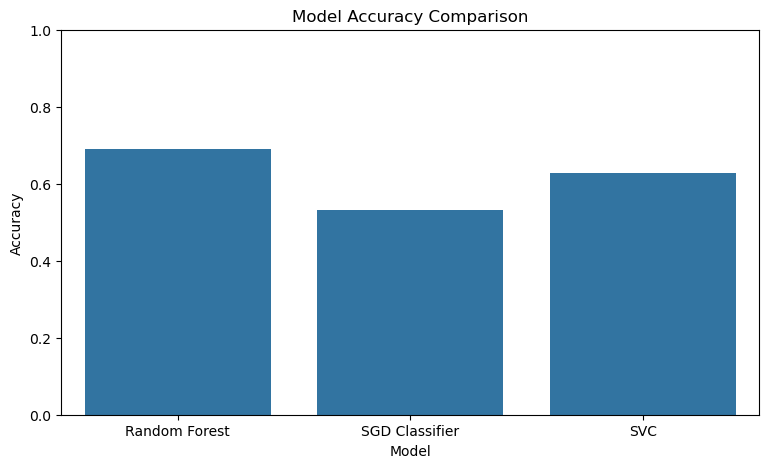

In [52]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=comparison,
    x='Model',
    y='Accuracy'
)

plt.title('Model Accuracy Comparison')
plt.ylim(0,1)

plt.show()

## Conclusion

* In this project, wine quality was converted into three categories: Low, Medium, and High. Exploratory data analysis showed that the original quality scores were imbalanced, with quality scores 5 and 6 representing most of the observations, while extreme quality scores were relatively rare.

* Three classification algorithms — Random Forest, SGD Classifier, and SVC — were trained using a stratified train/test split. Feature scaling was applied for SGD and SVC, while Random Forest was trained on the original feature values.

* The models were evaluated using accuracy, precision, recall, F1-score, and confusion matrices. Random Forest feature importance was also analyzed to identify the most influential physicochemical variables.

* Based on the evaluation results, [BEST MODEL] performed best overall. It achieved an accuracy of approximately [XX%] and provided the best balance between predictive performance and handling of the different quality classes.

* However, the minority High-quality class remains more difficult to predict because of its smaller representation in the dataset. Therefore, model selection should not be based only on accuracy; class-wise recall and F1-score should also be considered.